In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.switch_backend('Agg')

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

# Configure inline plotting
%matplotlib inline

# Set visual styles
sns.set(style="whitegrid")

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("cid007/mental-disorder-classification")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 2.17k/2.17k [00:00<00:00, 445kB/s]

Extracting files...
Path to dataset files: C:\Users\anast\.cache\kagglehub\datasets\cid007\mental-disorder-classification\versions\1


In [2]:
data = pd.read_csv(r'C:\Users\anast\.cache\kagglehub\datasets\cid007\mental-disorder-classification\versions\1\Dataset-Mental-Disorders.csv')
data

,Patient Number,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,Patiant-01,Usually,Seldom,Sometimes,Sometimes,YES,YES,NO,NO,YES,NO,NO,YES,YES,YES,3 From 10,3 From 10,4 From 10,Bipolar Type-2
1,Patiant-02,Usually,Seldom,Usually,Sometimes,NO,YES,NO,NO,NO,NO,NO,NO,NO,NO,4 From 10,2 From 10,5 From 10,Depression
2,Patiant-03,Sometimes,Most-Often,Sometimes,Sometimes,YES,NO,NO,NO,YES,YES,NO,YES,YES,NO,6 From 10,5 From 10,7 From 10,Bipolar Type-1
3,Patiant-04,Usually,Seldom,Usually,Most-Often,YES,YES,YES,NO,YES,NO,NO,NO,NO,NO,3 From 10,2 From 10,2 From 10,Bipolar Type-2
4,Patiant-05,Usually,Usually,Sometimes,Sometimes,NO,NO,NO,NO,NO,NO,NO,YES,YES,YES,5 From 10,5 From 10,6 From 10,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Patiant-116,Most-Often,Seldom,Usually,Sometimes,NO,YES,NO,NO,YES,NO,YES,NO,NO,YES,2 From 10,5 From 10,3 From 10,Depression
116,Patiant-117,Sometimes,Sometimes,Sometimes,Seldom,YES,NO,NO,NO,NO,YES,NO,NO,NO,YES,6 From 10,7 From 10,8 From 10,Bipolar Type-1
117,Patiant-118,Usually,Sometimes,Usually,Sometimes,YES,NO,YES,YES,NO,NO,NO,YES,NO,YES,1 From 10,5 From 10,3 From 10,Bipolar Type-2
118,Patiant-119,Usually,Sometimes,Seldom,Seldom,NO,YES,YES,NO,YES,YES,YES,NO,YES,YES,7 From 10,7 From 10,7 From 10,Depression


In [3]:
data=data.drop('Patient Number',axis=1)
if data.empty:
    raise ValueError('The input dataset is empty. Please check the file and its path.')

if set(data['Expert Diagnose'].str.lower().unique()) <= {"Normal","Bipolar Type-1", "Bipolar Type-2","Depression"}:
    data['Expert Diagnose'] = data['Expert Diagnose'].str.lower().map({'YES': 1, 'NO': 0})
else:
    le = LabelEncoder()
    data['Expert Diagnose'] = le.fit_transform(data['Expert Diagnose'])

df = pd.get_dummies(data, drop_first=True)

print("\nData after encoding:")
display(df.head())


Data after encoding:


,Expert Diagnose,Sadness_Seldom,Sadness_Sometimes,Sadness_Usually,Euphoric_Seldom,Euphoric_Sometimes,Euphoric_Usually,Exhausted_Seldom,Exhausted_Sometimes,Exhausted_Usually,...,Concentration_7 From 10,Concentration_8 From 10,Optimisim_2 From 10,Optimisim_3 From 10,Optimisim_4 From 10,Optimisim_5 From 10,Optimisim_6 From 10,Optimisim_7 From 10,Optimisim_8 From 10,Optimisim_9 From 10
0,1,0,0,1,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
1,2,0,0,1,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,1,0,0,1,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
4,3,0,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0


Accuracy Score: 0.8750


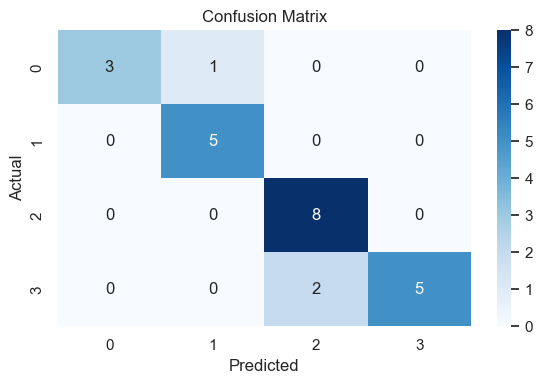

ROC Curve requires binary labels. Please ensure that the target variable is encoded correctly.


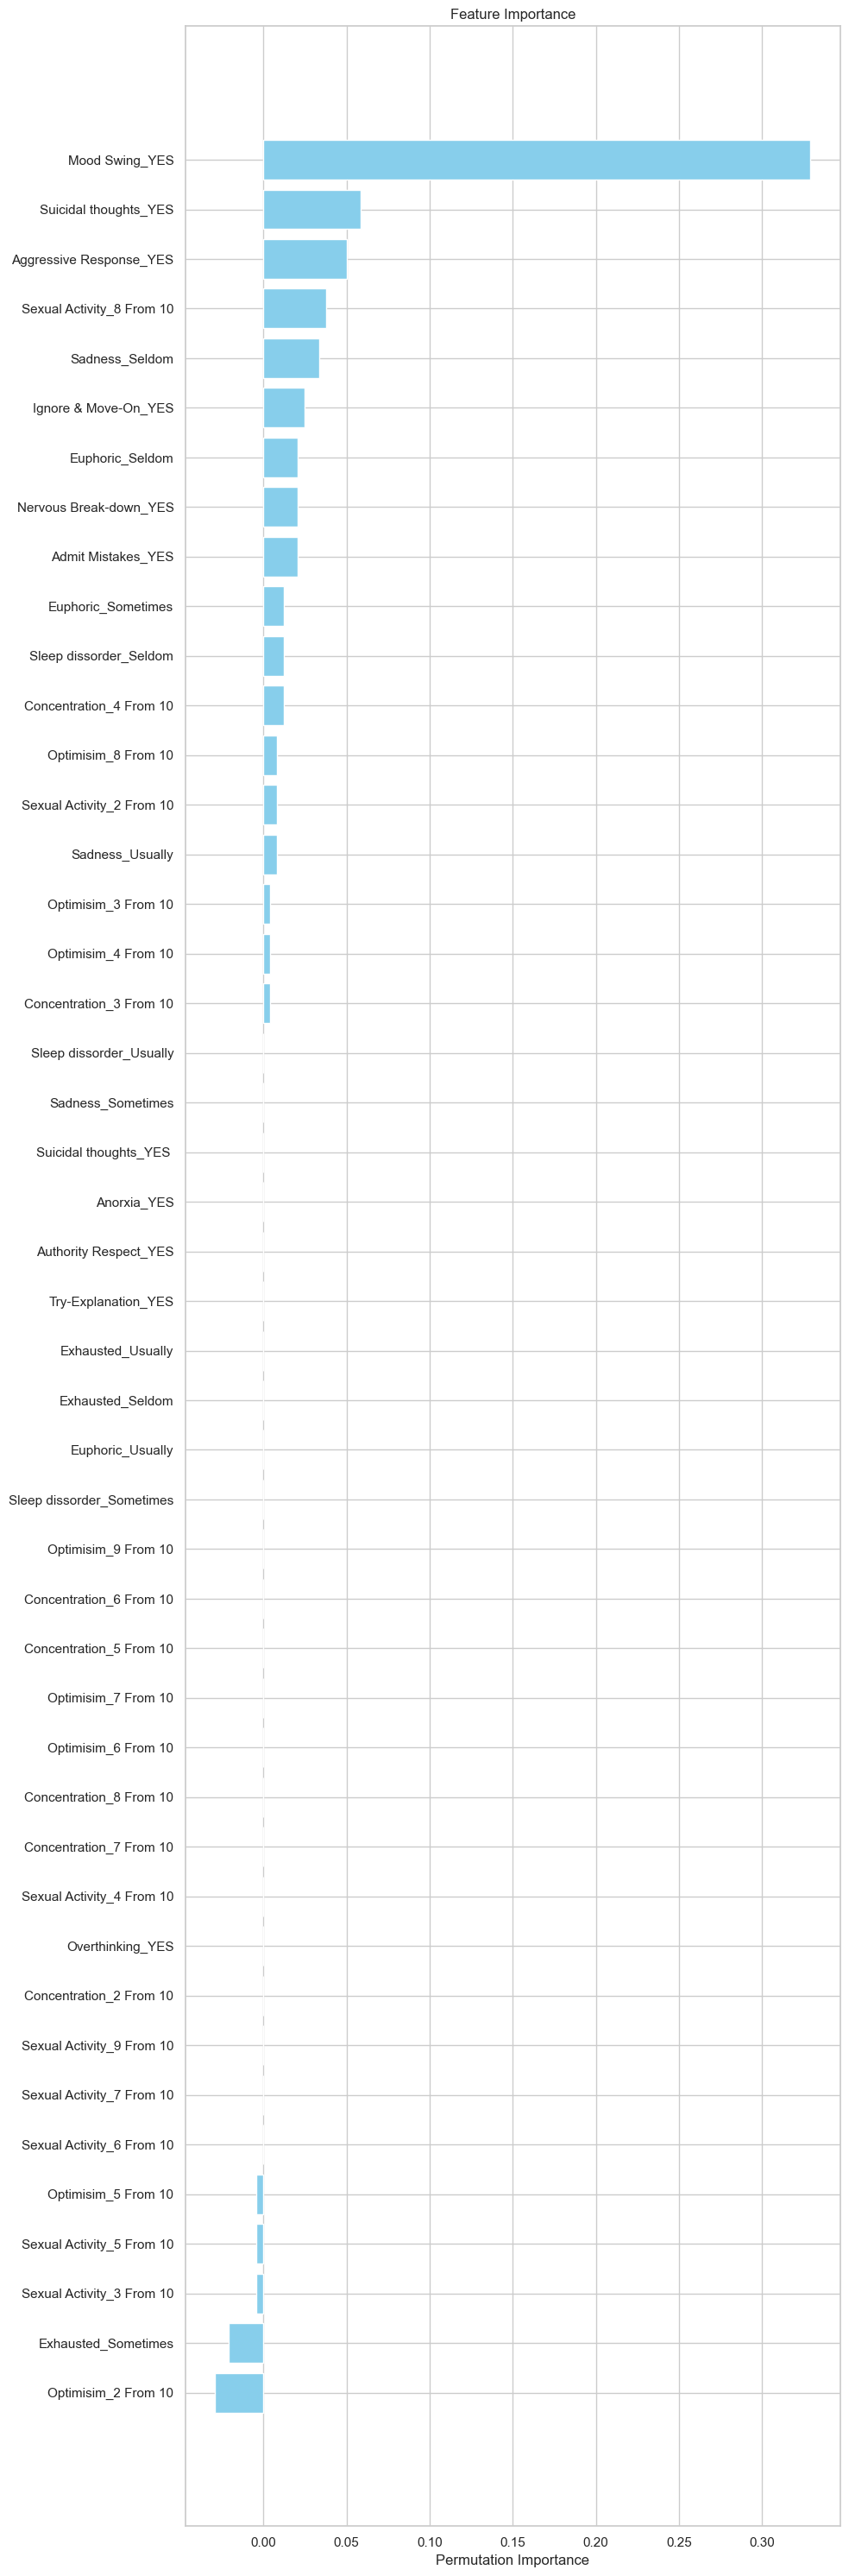

In [4]:
df.dropna(inplace=True)

X = df.drop('Expert Diagnose', axis=1)
y = df['Expert Diagnose']

if X.shape[0] == 0:
    raise ValueError('The feature matrix is empty after dropping NaNs. Check your data for extensive missing values.')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

if X_train.shape[0] == 0:
    raise ValueError('Training set is empty after splitting. Adjust the test_size or check the input data.')

model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f}')

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

if set(y_test.unique()) <= {0, 1}:
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('ROC Curve requires binary labels. Please ensure that the target variable is encoded correctly.')

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': result.importances_mean})
importance_df = importance_df.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 30))
plt.barh(importance_df['feature'], importance_df['importance'], color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

Accuracy Score: 1.0000


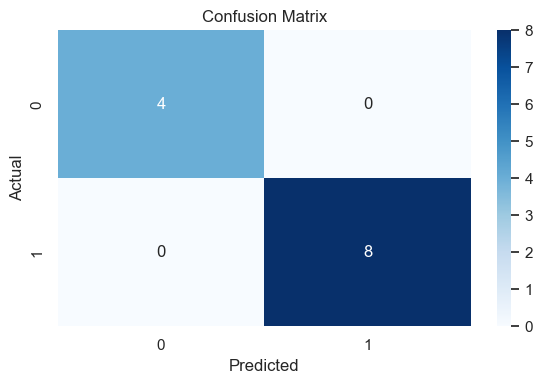

ROC Curve requires binary labels. Please ensure that the target variable is encoded correctly.


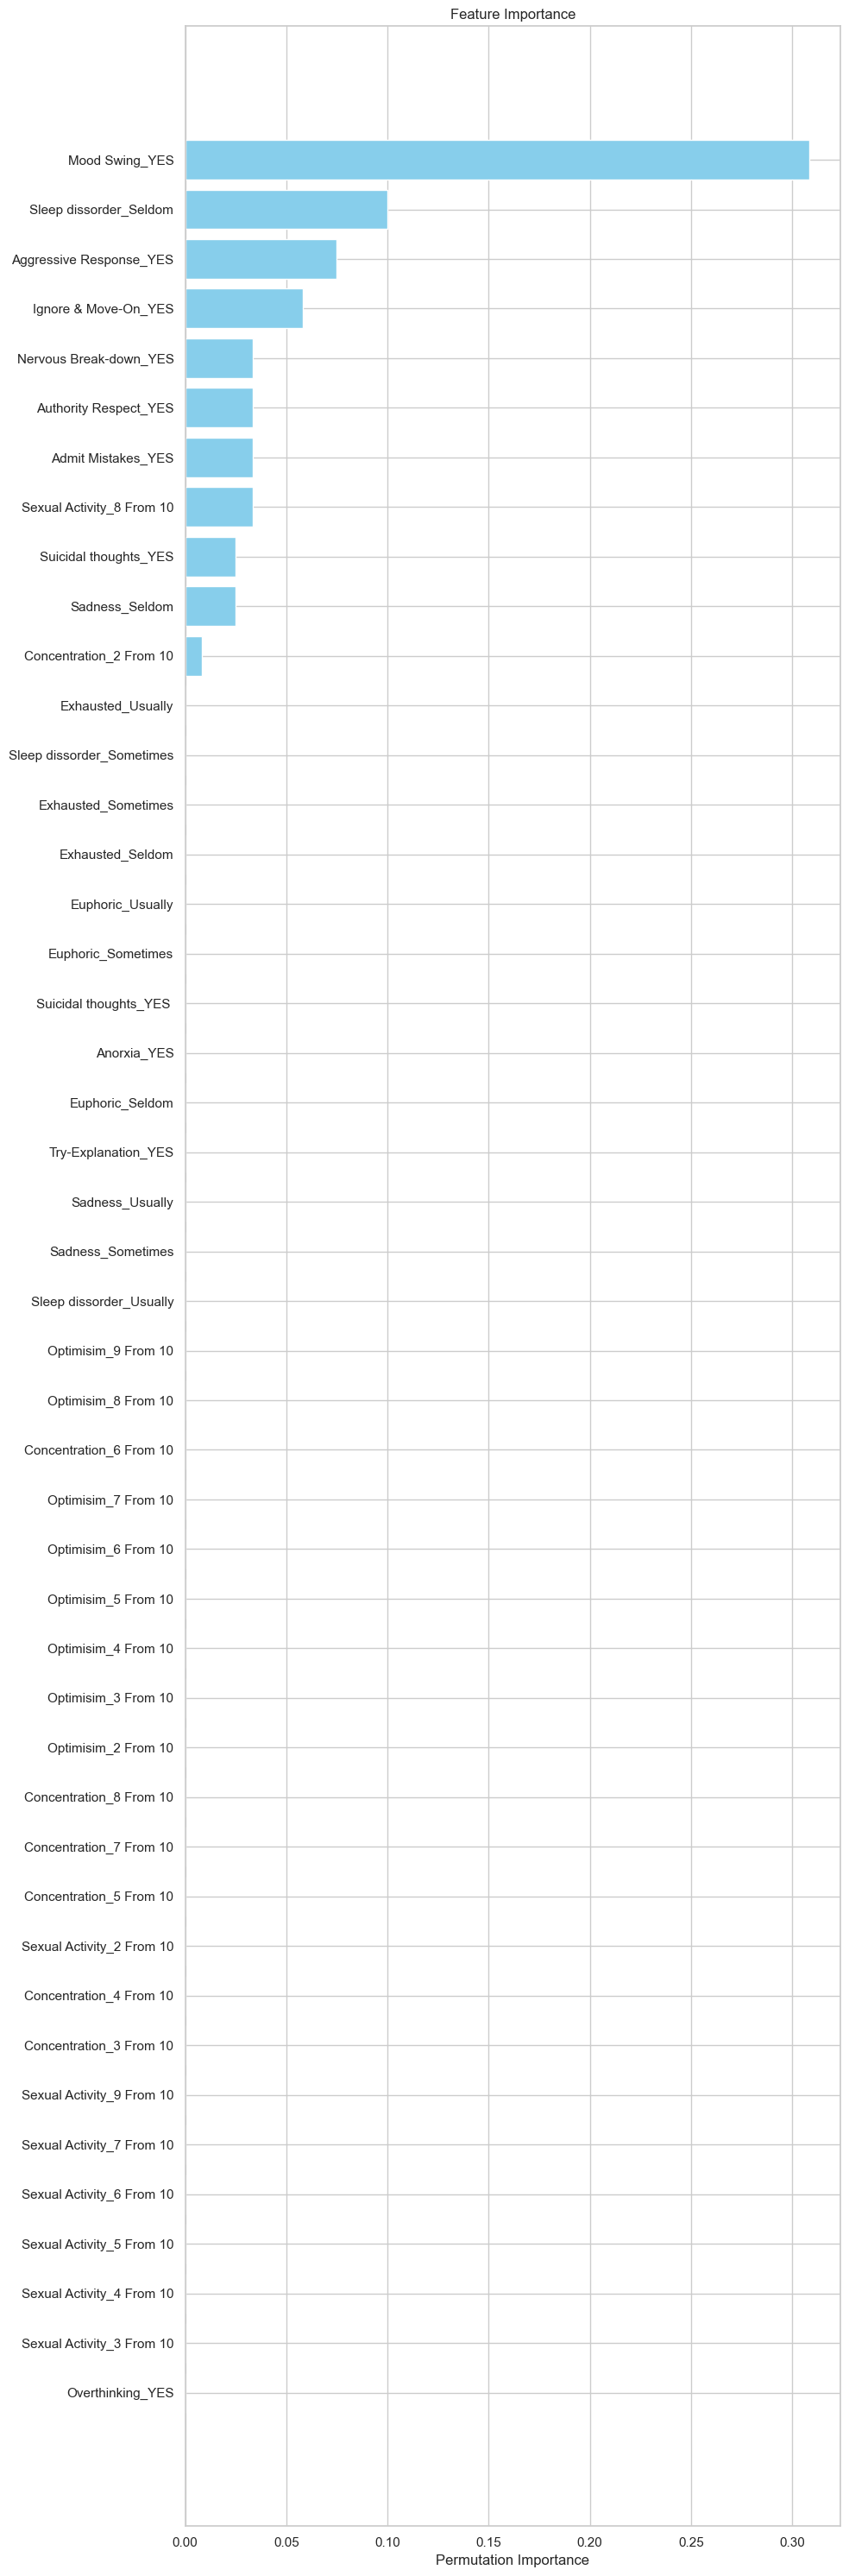

In [5]:
d=df[df['Expert Diagnose']!=1]
d=d[d['Expert Diagnose']!=2]

d.dropna(inplace=True)

X = d.drop('Expert Diagnose', axis=1)
y = d['Expert Diagnose']

if X.shape[0] == 0:
    raise ValueError('The feature matrix is empty after dropping NaNs. Check your data for extensive missing values.')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

if X_train.shape[0] == 0:
    raise ValueError('Training set is empty after splitting. Adjust the test_size or check the input data.')

model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f}')

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

if set(y_test.unique()) <= {0, 1}:
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('ROC Curve requires binary labels. Please ensure that the target variable is encoded correctly.')

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': result.importances_mean})
importance_df = importance_df.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 30))
plt.barh(importance_df['feature'], importance_df['importance'], color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

Accuracy Score: 0.7778


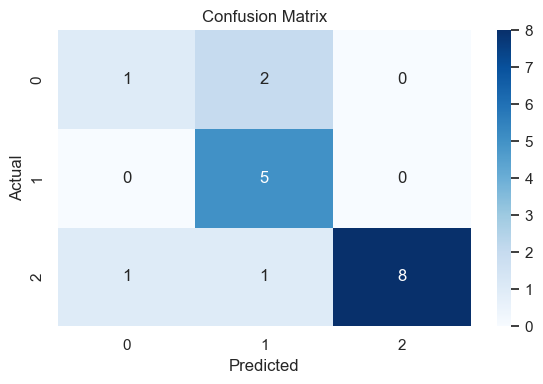

ROC Curve requires binary labels. Please ensure that the target variable is encoded correctly.


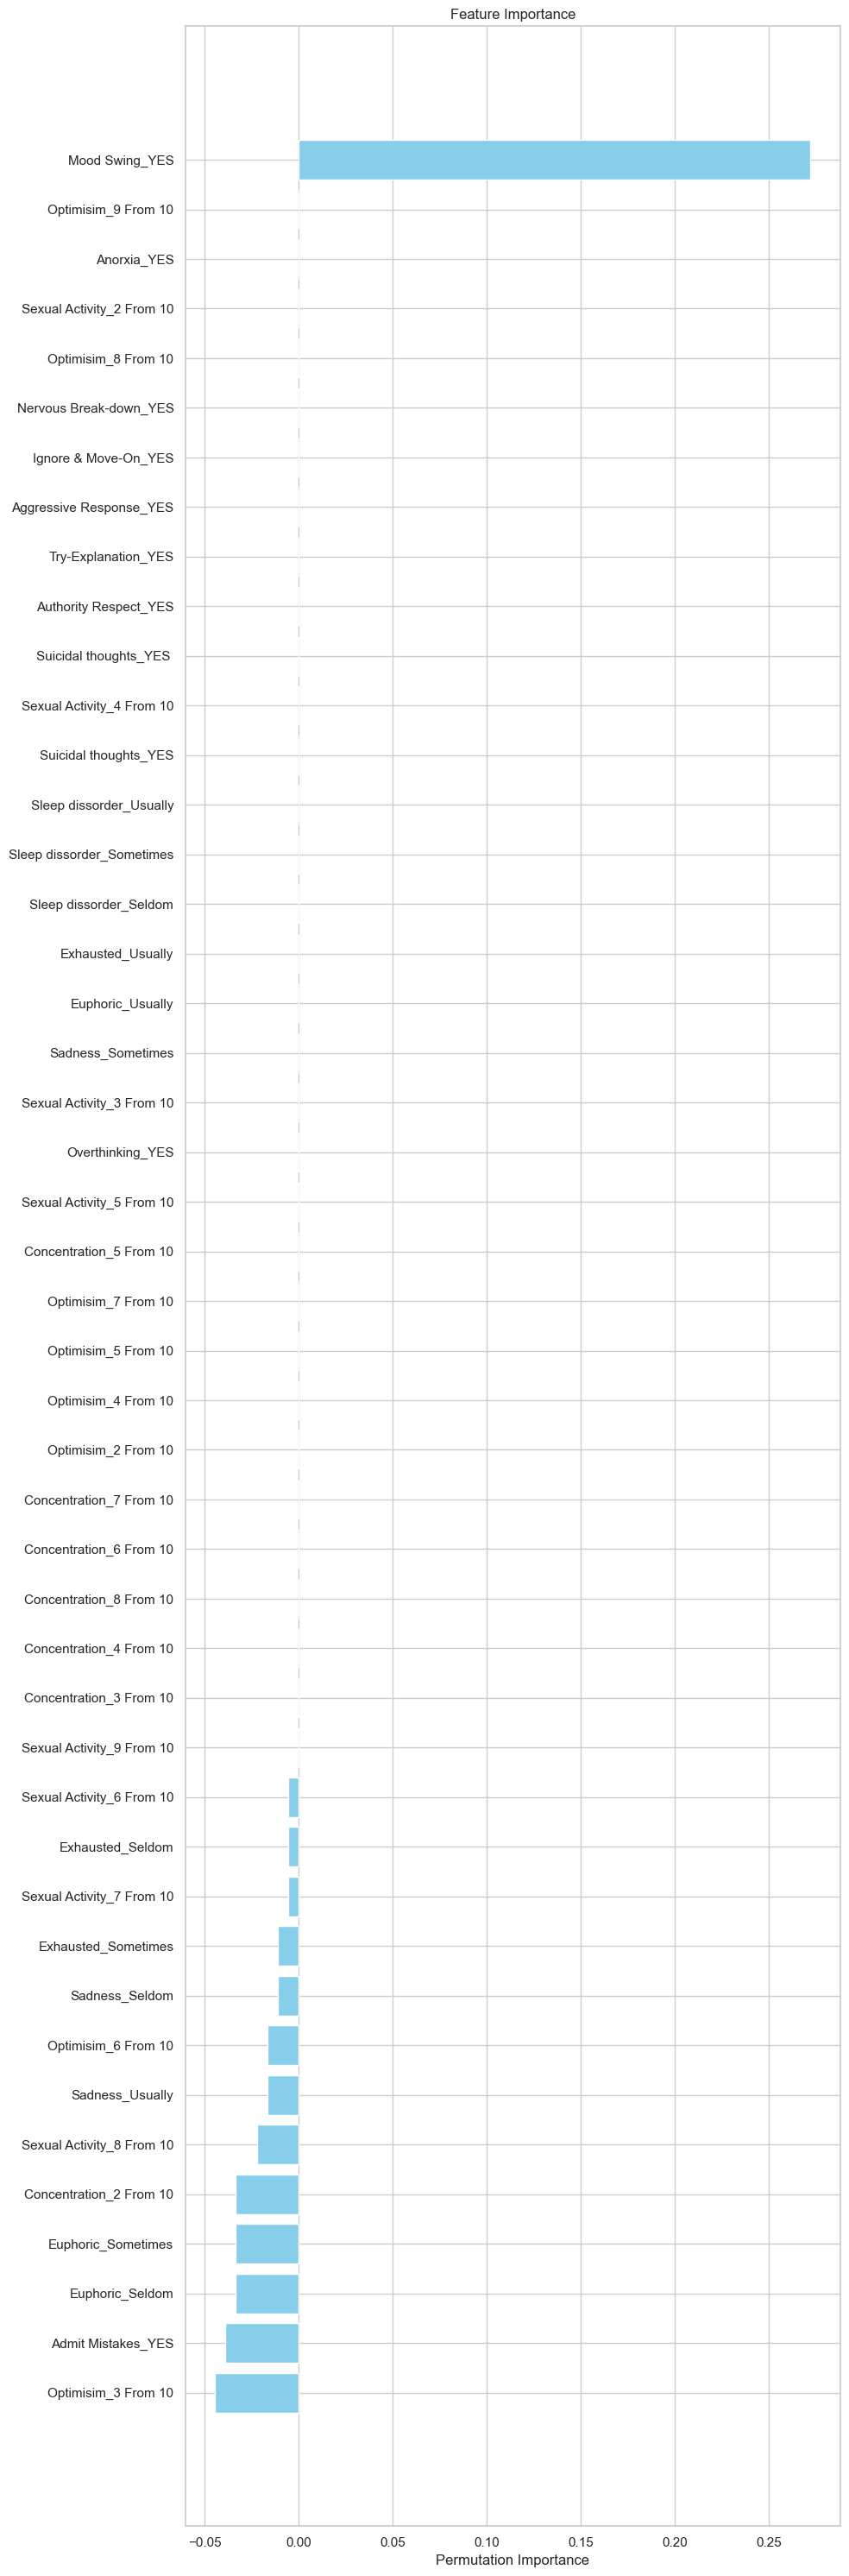

In [6]:
d=df[df['Expert Diagnose']!=3]

d.dropna(inplace=True)

X = d.drop('Expert Diagnose', axis=1)
y = d['Expert Diagnose']

if X.shape[0] == 0:
    raise ValueError('The feature matrix is empty after dropping NaNs. Check your data for extensive missing values.')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

if X_train.shape[0] == 0:
    raise ValueError('Training set is empty after splitting. Adjust the test_size or check the input data.')

model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f}')

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

if set(y_test.unique()) <= {0, 1}:
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('ROC Curve requires binary labels. Please ensure that the target variable is encoded correctly.')

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': result.importances_mean})
importance_df = importance_df.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 30))
plt.barh(importance_df['feature'], importance_df['importance'], color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

Accuracy Score: 1.0000


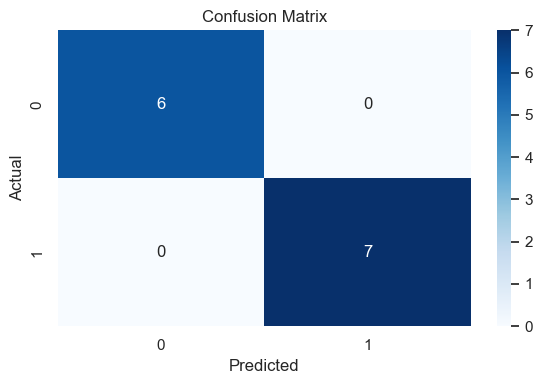

ROC Curve requires binary labels. Please ensure that the target variable is encoded correctly.


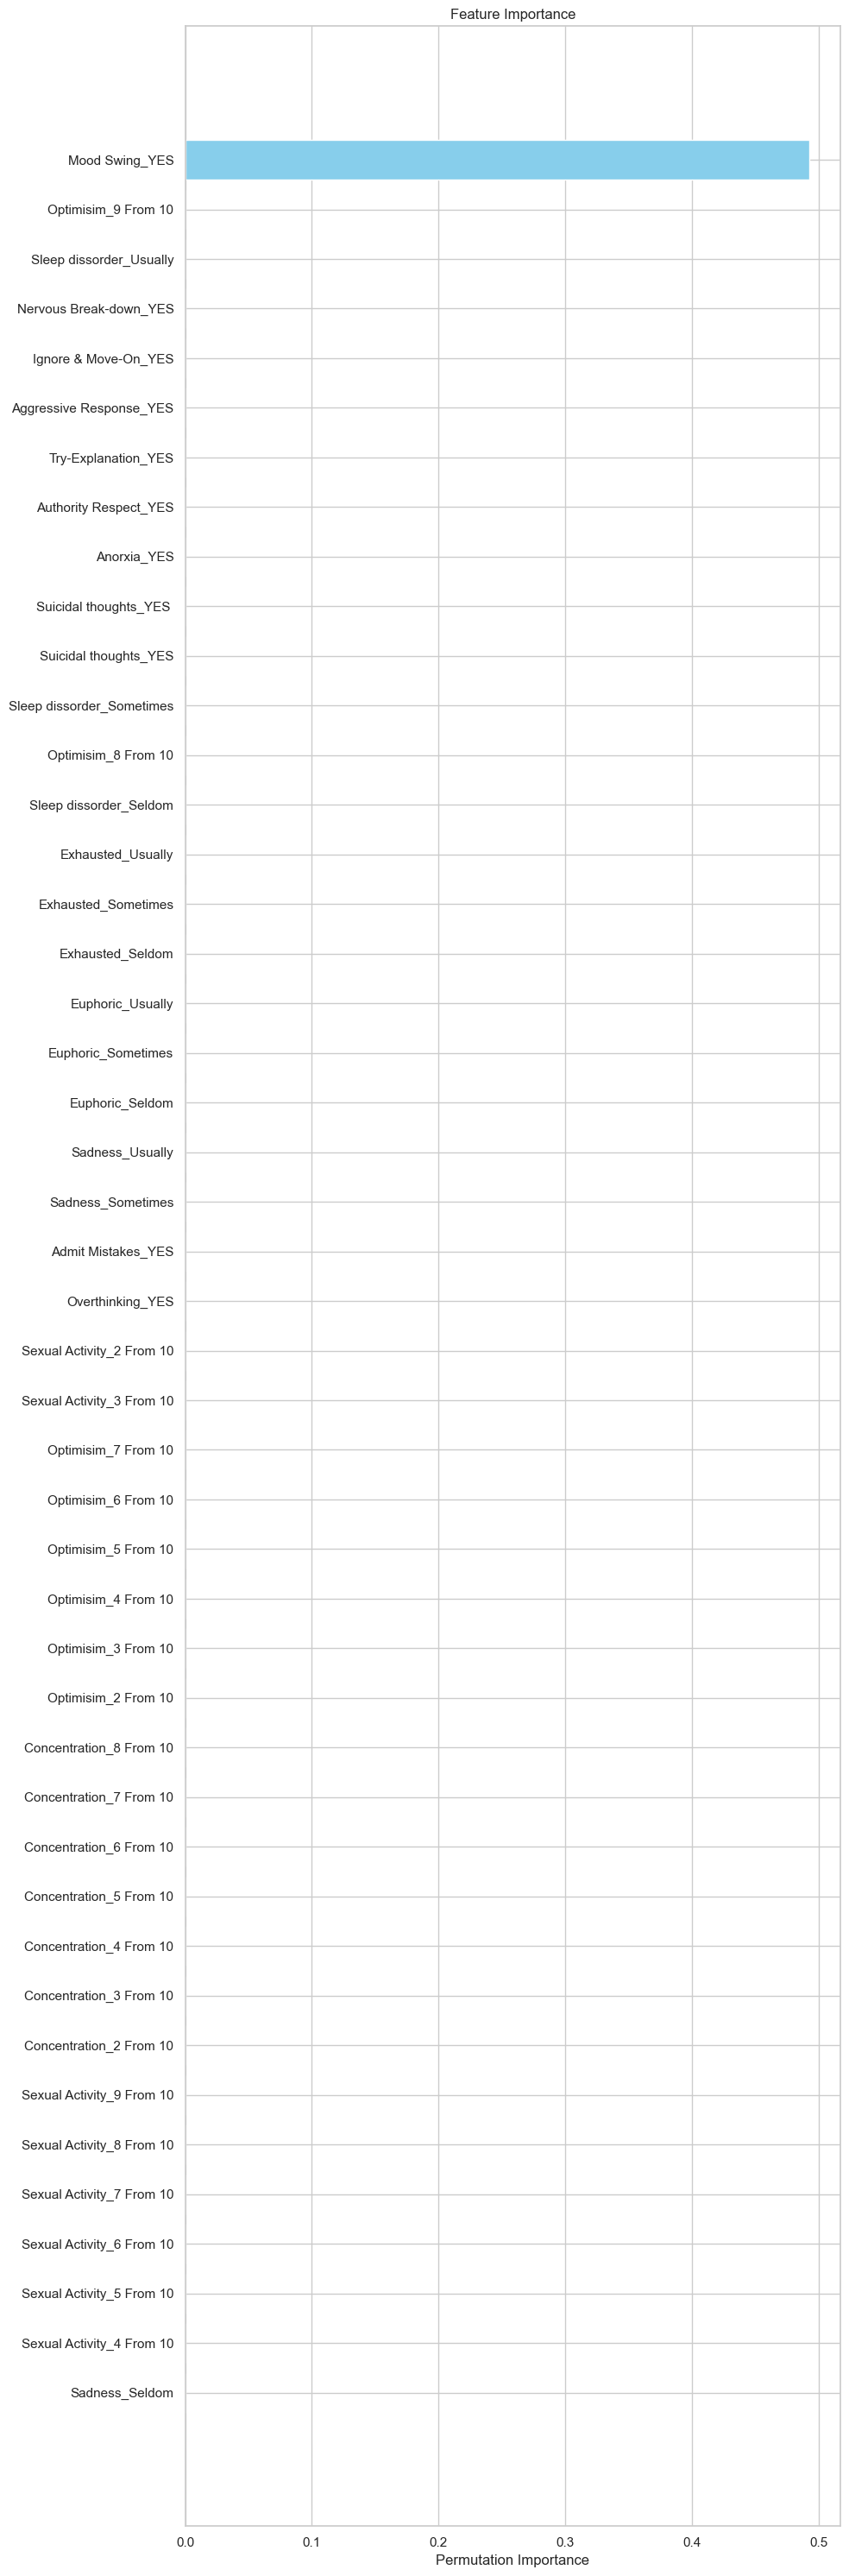

In [7]:
d=df[df['Expert Diagnose']!=3]
d=d[d['Expert Diagnose']!=0]

d.dropna(inplace=True)

X = d.drop('Expert Diagnose', axis=1)
y = d['Expert Diagnose']

if X.shape[0] == 0:
    raise ValueError('The feature matrix is empty after dropping NaNs. Check your data for extensive missing values.')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

if X_train.shape[0] == 0:
    raise ValueError('Training set is empty after splitting. Adjust the test_size or check the input data.')

model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f}')

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

if set(y_test.unique()) <= {0, 1}:
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('ROC Curve requires binary labels. Please ensure that the target variable is encoded correctly.')

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': result.importances_mean})
importance_df = importance_df.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 30))
plt.barh(importance_df['feature'], importance_df['importance'], color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()